# Once things are generated - what is selecting them like?

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from gaianir_open_clusters.config import RESULTS_DIRECTORY
from gaianir_open_clusters.gaia_nir_config import SIMULATION_CLUSTER_PARAMETERS

from hr_selection_function import HR24SelectionFunction, NStarsPredictor, GaiaDensityEstimator

from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde, multivariate_normal

from astropy.coordinates import SkyCoord
from astropy import units as u


In [2]:
simulated_clusters = pd.read_parquet(RESULTS_DIRECTORY / "simulated_clusters.parquet")

## Helper functions

In [3]:
def errors_to_median_error(pmra_error, pmdec_error, parallax_error):
    """Function that converts astrometric errors to the error needed for cluster
    density calculations.

    Adds a scale factor that accounts for an oversight in the Hunt+26 cluster selection
    function. In it, they assumed sigma_parallax = sigma_pmra = sigma_pmdec. This is
    true for Gaia DR3... only, due to the timespan of its observations. A correction
    factor is required to convert proper motions with a time baseline of anything other
    than 34 months to be scaled as if they're a parallax error.

    See https://www.cosmos.esa.int/web/gaia/science-performance
    """
    return (
        np.nanmedian(pmra_error)
        / 1.03
        * np.nanmedian(pmdec_error)
        / 0.89
        * np.nanmedian(parallax_error)
    ) ** (1 / 3)


def measure_cluster_density(
    members,
    magnitude_limits,
    use_combined=True,
    estimate_gaia_dr3_from_dr4=True,
    missions=("gaianir-l", "gaianir-m", "gaia_dr5", "gaia_dr4", "gaia_dr3"),
):
    result = dict()

    for mission in missions:
        maglim = magnitude_limits[mission]
        key_out = mission
        key_astrometry = mission

        pm_scale, parallax_scale = 1.0, 1.0
        if estimate_gaia_dr3_from_dr4 and mission == "gaia_dr3":
            key_astrometry = "gaia_dr4"
            parallax_scale = np.sqrt(66 / 34)
            pm_scale = 66 / 34 * parallax_scale

        subsample = members.loc[
            (members[key_astrometry]) & (members[maglim["band"]] < maglim["limit"])
        ]
        if use_combined and "gaianir" in mission:
            key_astrometry = key_astrometry + "_combined"

        result[f"n_stars_{key_out}"] = len(subsample)
        if len(subsample) > 0:
            result[f"med_error_{key_out}"] = errors_to_median_error(
                subsample[f"pmra_error_{key_astrometry}"] * pm_scale,
                subsample[f"pmdec_error_{key_astrometry}"] * pm_scale,
                subsample[f"parallax_error_{key_astrometry}"] * parallax_scale,
            )
        else:
            result[f"med_error_{key_out}"] = np.inf
        result[f"rho_cluster_{key_out}"] = (
            result[f"n_stars_{key_out}"] / result[f"med_error_{key_out}"] ** 3
        )

    return result


def measure_region_density(
    cluster_locations,
    region,
    region_area,
    magnitude_limits,
    stars_in_sample_desired: int = 50,
    stars_in_sample_minimum: int = 5,
    stars_in_sample_region_scale: float | int = 3,
    parallax_move_amount=0.1,
    missions=("gaianir-l", "gaianir-m", "gaia_dr5", "gaia_dr4", "gaia_dr3"),
    use_combined: bool = True,
    bandwidth_method: str = "scott",
):
    # Firstly, cut to just valid stars
    result = dict()

    for mission in missions:
        maglim = magnitude_limits[mission]
        key_out = mission
        key_proper_motion = mission
        key_parallax = mission

        if use_combined and "gaianir" in mission:
            key_proper_motion = key_proper_motion + "_combined"

        key_crowding = f"uncrowded_{mission.replace('_dr4', '').replace('_dr5', '').replace('_dr3', '')}"  # todo this is ugly af
        region_valid = region.loc[
            (region[key_crowding])
            & (
                region[maglim["band"].replace("g_effective_gaia", "gaia_dr3_g")]
                < maglim["limit"]
            )
        ]
        # if len(region_valid) < minimum_stars_in_sample:
        #     raise ValueError(
        #         f"valid region contains too few stars {len(region_valid)} - consider "
        #         "increasing minimum_stars_in_sample"
        #     )

        this_minimum_stars = np.clip(
            len(region_valid) / stars_in_sample_region_scale,
            stars_in_sample_minimum,
            stars_in_sample_desired,
        )

        # Iterate over each parallax/cluster pm and identify its data density
        for i_row, a_row in cluster_locations.iterrows():
            # Get a sample of stars
            parallax_var = parallax_move_amount
            subsample = []
            while len(subsample) < this_minimum_stars:
                subsample = region_valid.loc[
                    (
                        region_valid[f"parallax_{key_parallax}"]
                        > a_row["parallax"] - parallax_var
                    )
                    & (
                        region_valid[f"parallax_{key_parallax}"]
                        < a_row["parallax"] + parallax_var
                    )
                ]
                parallax_var *= 2

            # Do a KDE to estimate the density at this point
            # kde = gaussian_kde(
            #     subsample[[f"pmra_{key_proper_motion}", f"pmdec_{key_proper_motion}"]]
            #     .to_numpy()
            #     .T,
            #     bw_method=bandwidth_method,
            # )
            # background_density = kde([a_row["pmra"], a_row["pmdec"]])

            # Do a multivariate normal to estimate the density at this point
            X = subsample[[f"pmra_{key_proper_motion}", f"pmdec_{key_proper_motion}"]]
            mean = np.mean(X, axis=0)
            cov = np.cov(X.T)
            single_multivariate = multivariate_normal(mean, cov)
            background_density = single_multivariate.pdf(
                [a_row["pmra"], a_row["pmdec"]]
            )

            # Scale everything based on scale factors so that rho_data
            # is correct - i.e., n_stars mas^{-3} yr^{2} field^{-1}
            width = parallax_var * 2
            cluster_locations.loc[i_row, f"rho_data_{key_out}"] = (
                len(subsample)
                * background_density
                / width  # Parallax width
                / region_area  # Area of underlying simulated region
                * 30.21  # HR23 clustering field area
            )

            # Also record the number of stars, just out of curiosity
            cluster_locations.loc[i_row, f"n_stars_for_rho_data_{key_out}"] = len(
                subsample
            )

    return cluster_locations


def add_gaia_dr3_uncertainties_based_on_sampling(region, seed=None):
    """Adds approximate Gaia DR3 observations to a region, based back-extrapolating from
    Gaia DR4.
    """
    # Make errors based on scale factors
    parallax_scale = np.sqrt(66 / 34)
    pm_scale = 66 / 34 * parallax_scale

    region["pmra_error_gaia_dr3"] = region["pmra_error_gaia_dr4"] * pm_scale
    region["pmdec_error_gaia_dr3"] = region["pmdec_error_gaia_dr4"] * pm_scale
    region["parallax_error_gaia_dr3"] = (
        region["parallax_error_gaia_dr4"] * parallax_scale
    )

    # Resample based on scale factors
    rng = np.random.default_rng(seed)

    region["pmra_gaia_dr3"] = rng.normal(
        loc=region["pmra_true"], scale=region["pmra_error_gaia_dr4"]
    )
    region["pmdec_gaia_dr3"] = rng.normal(
        loc=region["pmdec_true"], scale=region["pmdec_error_gaia_dr4"]
    )
    region["parallax_gaia_dr3"] = rng.normal(
        loc=region["parallax_true"], scale=region["parallax_error_gaia_dr4"]
    )

    return region


## Measure densities

In [4]:
simulated_clusters = pd.read_parquet(RESULTS_DIRECTORY / "simulated_clusters.parquet")

coords = (
    SkyCoord(
        l=simulated_clusters["l"].to_numpy() * u.deg,
        b=simulated_clusters["b"].to_numpy() * u.deg,
        distance=simulated_clusters["distance"].to_numpy() * u.pc,
        frame="galactic",
    )
    .transform_to("galactocentric")
    .represent_as("cylindrical")
)
simulated_clusters["r_gc"] = coords.rho.to(u.pc).value
simulated_clusters = simulated_clusters.query("r_gc < 20000")

In [5]:
magnitude_limits = {
    "gaianir-l": {"band": "gaianir_n", "limit": 20.5},
    "gaianir-m": {"band": "gaianir_n", "limit": 20},
    "gaia_dr5": {"band": "g_effective_gaia", "limit": 19},
    "gaia_dr4": {"band": "g_effective_gaia", "limit": 18.5},
    "gaia_dr3": {"band": "g_effective_gaia", "limit": 18},
}

In [6]:
cluster_density_df = {}
for i_row, a_row in simulated_clusters.iterrows():
    print(f"\r{i_row+1} of {len(simulated_clusters)}", end="")
    members = pd.read_parquet(RESULTS_DIRECTORY / a_row["path"])
    cluster_density_df[i_row] = measure_cluster_density(members, magnitude_limits)

cluster_density_df = pd.DataFrame.from_dict(cluster_density_df, orient="index")

2832 of 2396

In [7]:
simulated_clusters_with_density = simulated_clusters.join(cluster_density_df)

[Text(0.5, 1.0, 'n_stars')]

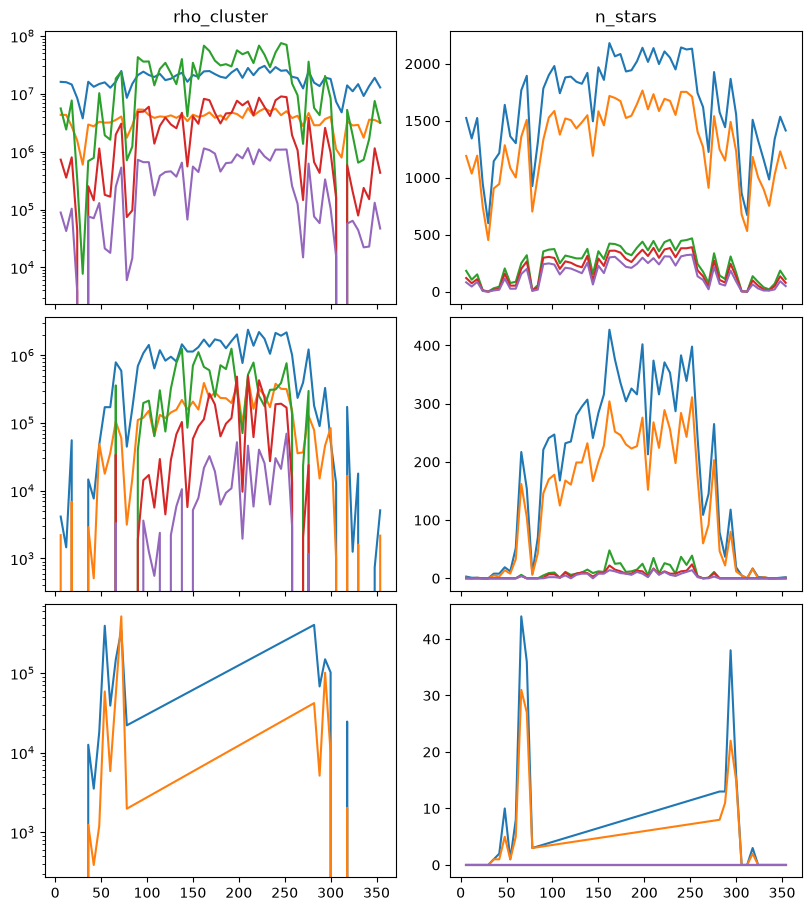

In [8]:
cluster = "berkeley_29"
distances = [2000, 10000, 20000]

fig, ax = plt.subplots(
    nrows=len(distances),
    ncols=2,
    figsize=(8, 3 * len(distances)),
    layout="constrained",
    sharex=True,
)

for an_ax, distance in zip(ax, distances):
    subsample = simulated_clusters_with_density.query(
        f"cluster=='{cluster}' and distance=={distance}"
    )
    for a_mission in magnitude_limits:
        an_ax[0].plot(
            subsample["l"], subsample[f"rho_cluster_{a_mission}"], label=a_mission
        )
        an_ax[1].plot(subsample["l"], subsample[f"n_stars_{a_mission}"])

    an_ax[0].set(yscale="log")
    # an_ax[1].set(yscale="log")

ax[0, 0].set(title="rho_cluster")
ax[0, 1].set(title="n_stars")

In [9]:
unique_locations = simulated_clusters[
    ["l", "b", "distance", "pmra", "pmdec", "path_region"]
].drop_duplicates().sort_values(["l", "b", "distance"]).reset_index(drop=True)

unique_locations['parallax'] = 1000 / unique_locations['distance']

In [10]:
region_density_df = []
paths = unique_locations["path_region"].unique()
for i, short_path_region in enumerate(paths):
    print(f"\r{i + 1} of {len(paths)}", end="")

    valid_clusters = unique_locations.query(f"path_region=='{short_path_region}'")

    path_region = RESULTS_DIRECTORY / short_path_region
    path_metadata = path_region.parent / (path_region.stem + "_metadata.pickle")
    region = pd.read_parquet(path_region)
    region = add_gaia_dr3_uncertainties_based_on_sampling(region)

    with open(RESULTS_DIRECTORY / path_metadata, "rb") as file:
        region_area = pickle.load(file)["area"]

    region_density_df.append(
        measure_region_density(
            valid_clusters,
            region,
            region_area,
            magnitude_limits,
        )
    )

region_density_df = pd.concat(region_density_df, ignore_index=True).drop(
    columns=["path_region", "parallax"]
)

59 of 59

In [11]:
simulated_clusters_full = simulated_clusters_with_density.merge(
    region_density_df, on=["l", "b", "distance", "pmra", "pmdec"], how="left"
)

## Add empirical results from DR3

In [12]:
n_stars_predictor = NStarsPredictor(models=100)
density_estimator = GaiaDensityEstimator()
# simulated_clusters_with_density

In [13]:
coords = SkyCoord(
    ra=simulated_clusters_full["ra"].to_numpy() * u.deg,
    dec=simulated_clusters_full["dec"].to_numpy() * u.deg,
    pm_ra_cosdec=simulated_clusters_full["pmra"].to_numpy() * u.mas / u.yr,
    pm_dec=simulated_clusters_full["pmdec"].to_numpy() * u.mas / u.yr,
    distance=simulated_clusters_full["distance"].to_numpy() * u.pc,
    frame="icrs",
)

simulated_clusters_full["metallicty"] = 0.0

(
    simulated_clusters_full["n_stars_gaia_dr3_empirical"],
    simulated_clusters_full["med_error_gaia_dr3_empirical"],
) = n_stars_predictor(coords, simulated_clusters_full)

simulated_clusters_full["rho_data_gaia_dr3_empirical"] = density_estimator(
    simulated_clusters_full["l"],
    simulated_clusters_full["b"],
    simulated_clusters_full["pmra"],
    simulated_clusters_full["pmdec"],
    1000 / simulated_clusters_full["distance"],
)

Querying model 100 of 100


## Calculate detectability

In [14]:
missions_done = (
    "gaianir-l",
    "gaianir-m",
    "gaia_dr5",
    "gaia_dr4",
    "gaia_dr3",
    "gaia_dr3_empirical",
)

In [24]:
selection_function = HR24SelectionFunction()

for mission in missions_done:
    good_points = np.logical_and(
        np.isfinite(simulated_clusters_full[f"med_error_{mission}"]),
        simulated_clusters_full[f"n_stars_{mission}"] != 0,
    )
    simulated_clusters_full[f"probability_{mission}"] = 0.0
    correction_factor = 1.0
    if "empirical" not in mission:
        correction_factor *= (
            simulated_clusters_full.loc[good_points, f"n_stars_{mission}"]
            / np.where(
                simulated_clusters_full.loc[good_points, "n_stars_gaia_dr3"] != 0,
                simulated_clusters_full.loc[good_points, "n_stars_gaia_dr3"],
                1,
            )
        )**(2/3)
        # spatial_density_nir = (
        #     simulated_clusters_full.loc[good_points, f"n_stars_{mission}"]
        #     / simulated_clusters_full.loc[
        #         good_points, f"n_stars_for_rho_data_{mission}"
        #     ]
        # )
        # spatial_density_dr3 = (
        #     np.where(
        #         simulated_clusters_full.loc[good_points, "n_stars_gaia_dr3"] != 0,
        #         simulated_clusters_full.loc[good_points, "n_stars_gaia_dr3"],
        #         0.1,
        #     )
        #     / simulated_clusters_full.loc[good_points, "n_stars_for_rho_data_gaia_dr3"]
        # )
        # correction_factor = (spatial_density_nir / spatial_density_dr3) ** (-2 / 3)

    simulated_clusters_full.loc[good_points, f"probability_{mission}"] = (
        selection_function(
            simulated_clusters_full.loc[good_points, f"rho_data_{mission}"],
            simulated_clusters_full.loc[good_points, f"n_stars_{mission}"],
            simulated_clusters_full.loc[good_points, f"med_error_{mission}"] ** (1 / 3)
            / correction_factor,
            np.full(good_points.sum(), 3.0),
        )
    )
    # simulated_clusters_full[f"probability_{mission}"] = (
    #     simulated_clusters_full[f"n_stars_{mission}"] >= 50
    # ).astype(float)

In [48]:
test_probability = 0.9
test_cluster = "berkeley_29"

l_values = simulated_clusters_full["l"].unique()
detectabilities = {mission: [] for mission in missions_done}
for l in l_values:
    subsample = simulated_clusters_full.query(f"cluster=='{test_cluster}' and l=={l}")
    max_distance = subsample["distance"].max()

    for mission in missions_done:
        distances, probabilities = (
            subsample[["distance", f"probability_{mission}"]].to_numpy().T
        )
        is_below = probabilities < test_probability
        false_values = is_below.nonzero()[0]

        # If everything is detected, just set to max distance
        if len(false_values) == 0:
            detectabilities[mission].append(max_distance)
            continue

        # If it's never detected, set to zero
        first_false_value = false_values[0]
        if first_false_value == 0:
            detectabilities[mission].append(0)
            continue

        # Otherwise, interpolate between the two sides
        slicer = slice(first_false_value - 1, first_false_value + 1)
        detectabilities[mission].append(
            np.interp(
                test_probability, probabilities[slicer][::-1], distances[slicer][::-1]
            )
        )


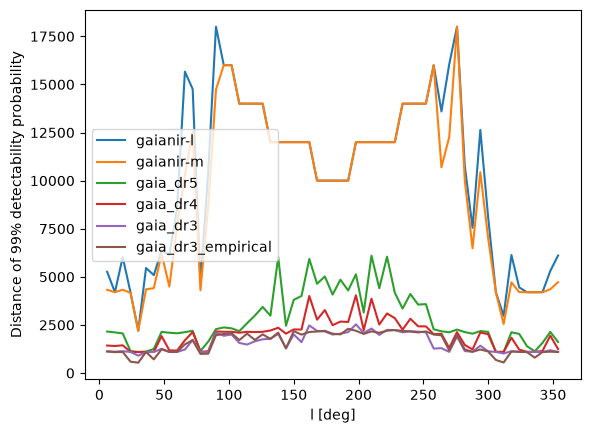

In [49]:
for mission in detectabilities:
    plt.plot(l_values, detectabilities[mission], label=mission)

plt.gca().set(xlabel="l [deg]", ylabel=r"Distance of 99% detectability probability")
plt.legend()

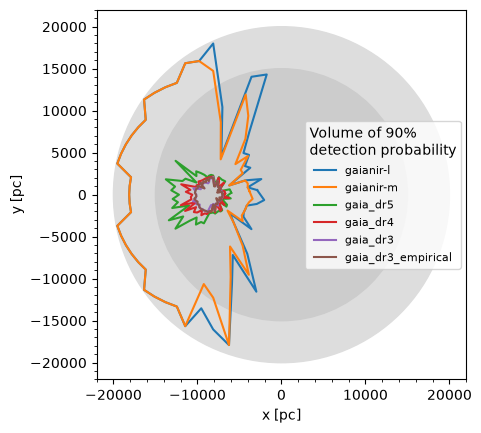

In [50]:
for mission in detectabilities:
    coord = SkyCoord(
        l=np.asarray(l_values) * u.deg,
        b=np.zeros_like(l_values) * u.deg,
        distance=np.asarray(detectabilities[mission]) * u.pc,
        frame="galactic"
    ).transform_to("galactocentric").represent_as("cartesian")
    x_values = coord.x.value
    y_values = coord.y.value
    x_values = np.append(x_values, x_values[0])
    y_values = np.append(y_values, y_values[0])
    plt.plot(x_values, y_values, label=mission)

# xlim, ylim = plt.gca().get_xlim(), plt.gca().get_ylim()

plt.gca().add_patch(plt.Circle((0, 0), radius=20000, color="#ddd"))
plt.gca().add_patch(plt.Circle((0, 0), radius=15000, color="#ccc"))

# plt.gca().set(xlim=xlim, ylim=ylim)

plt.gca().set(xlabel="x [pc]", ylabel="y [pc]", aspect="equal")
plt.legend(title=f"Volume of {test_probability:.0%}\ndetection probability", fontsize=8)
plt.gca().minorticks_on()

## Diagnostic plots

[None, None]

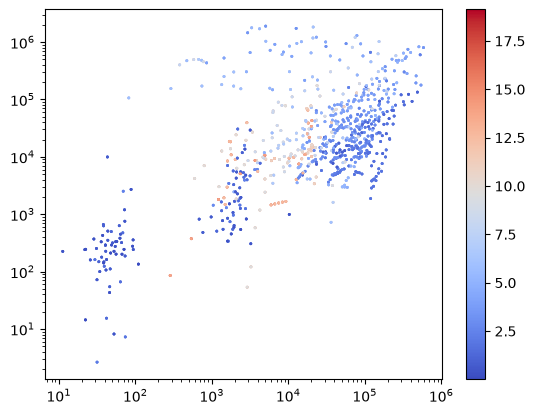

In [254]:
plt.scatter(
    simulated_clusters_full["rho_data_gaia_dr3_empirical"],
    simulated_clusters_full["rho_data_gaia_dr3"],
    s=1,
    # c=np.where(
    #     simulated_clusters_full["l"] > 180,
    #     simulated_clusters_full["l"] - 360,
    #     simulated_clusters_full["l"],
    # ),
    c=simulated_clusters_full['extinction'],
    cmap="coolwarm"
)
plt.colorbar()
plt.gca().set(xscale="log", yscale="log")

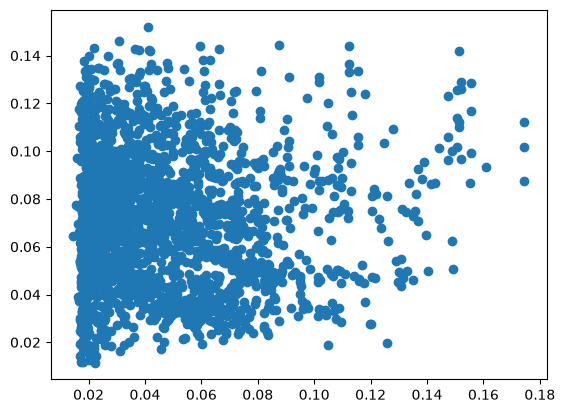

In [253]:
plt.scatter(
    simulated_clusters_full["med_error_gaia_dr3_empirical"],
    simulated_clusters_full["med_error_gaia_dr3"],
)
# plt.gca().set(xscale="log", yscale="log")
# plt.gca().set(aspect="equal", adjustable="datalim")

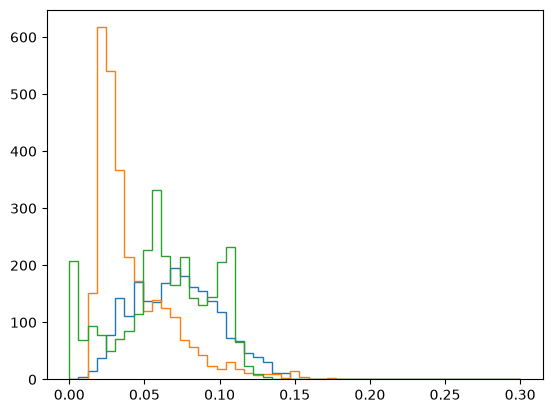

In [251]:
# _ = plt.hist(simulated_clusters_full["med_error_gaia_dr3"]+0.018, bins=np.linspace(0, 0.1))
_ = plt.hist(simulated_clusters_full["med_error_gaia_dr3"], bins=np.linspace(0, 0.3), histtype="step")
_ = plt.hist(simulated_clusters_full["med_error_gaia_dr3_empirical"], bins=np.linspace(0, 0.3), histtype="step")
_ = plt.hist(simulated_clusters_full["med_error_gaianir-l"], bins=np.linspace(0, 0.3), histtype="step")

[None, None]

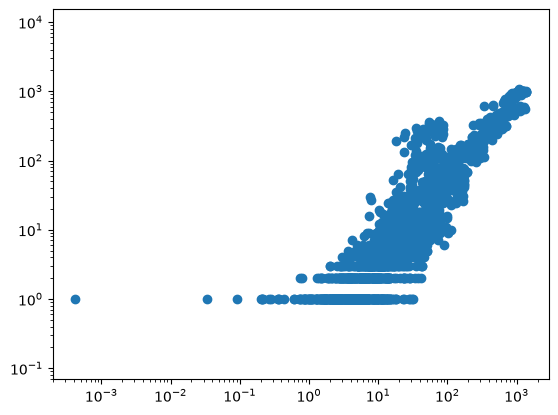

In [249]:
plt.scatter(
    simulated_clusters_full["n_stars_gaia_dr3_empirical"],
    simulated_clusters_full["n_stars_gaia_dr3"],
)
plt.gca().set(xscale="log", yscale="log")
plt.gca().set(aspect="equal", adjustable="datalim")

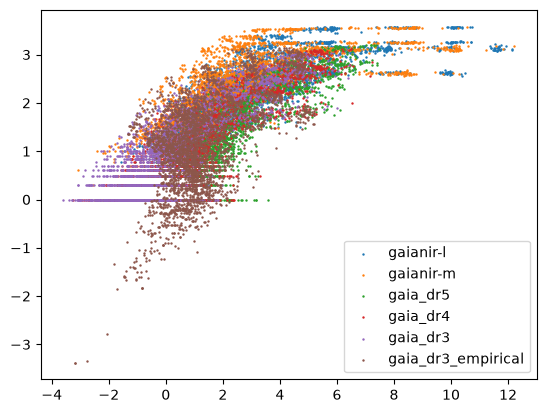

In [278]:
for mission in detectabilities:
    rho_hat = (
        simulated_clusters_full[f"n_stars_{mission}"]
        / simulated_clusters_full[f"med_error_{mission}"] ** 3
        / simulated_clusters_full[f"rho_data_{mission}"]
    )
    if "empirical" not in mission:
        rho_hat *= (
            simulated_clusters_full[f"n_stars_{mission}"]
            / np.where(
                simulated_clusters_full["n_stars_gaia_dr3"] != 0,
                simulated_clusters_full["n_stars_gaia_dr3"],
                1,
            )
        ) ** 2
    plt.scatter(
        np.log10(rho_hat),
        np.log10(simulated_clusters_full[f"n_stars_{mission}"]),
        label=mission,
        s=3,
        linewidths=0,
    )
plt.legend()

[None, None]

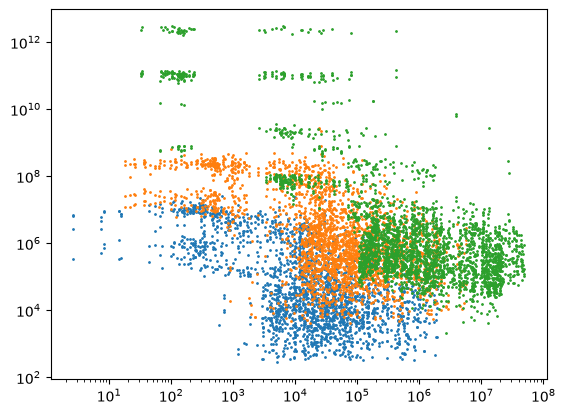

In [259]:
plt.scatter(
    simulated_clusters_full["rho_data_gaia_dr3"],
    simulated_clusters_full["rho_cluster_gaia_dr3"],
    s=1,
)
plt.scatter(
    simulated_clusters_full["rho_data_gaia_dr5"],
    simulated_clusters_full["rho_cluster_gaia_dr5"],
    s=1,
)
plt.scatter(
    simulated_clusters_full["rho_data_gaianir-l"],
    simulated_clusters_full["rho_cluster_gaianir-l"],
    s=1,
)
plt.gca().set(xscale="log", yscale="log")

In [434]:
region_density_df

,l,b,distance,pmra,pmdec,rho_data_gaianir-l,n_stars_for_rho_data_gaianir-l,rho_data_gaianir-m,n_stars_for_rho_data_gaianir-m,rho_data_gaia_dr5,n_stars_for_rho_data_gaia_dr5,rho_data_gaia_dr4,n_stars_for_rho_data_gaia_dr4,rho_data_gaia_dr3,n_stars_for_rho_data_gaia_dr3
0,0.0,0.0,500.0,-0.638572,-7.372577,4.273091e+05,5556.0,1.512939e+04,141.0,23844.601244,335.0,18168.534542,243.0,9917.499881,147.0
1,0.0,0.0,1000.0,-0.296374,-3.648754,2.757914e+05,576.0,5.442363e+05,1124.0,25625.563910,62.0,23908.979675,61.0,30607.254205,147.0
2,0.0,0.0,2000.0,-0.197843,-1.905723,1.786582e+05,95.0,3.598582e+05,125.0,119522.774894,219.0,88825.292131,158.0,56127.673321,103.0
3,0.0,0.0,4000.0,-0.419851,-1.478599,3.937316e+06,1417.0,4.143166e+06,1703.0,265105.732712,121.0,144939.731497,81.0,132090.060689,61.0
4,0.0,0.0,6000.0,-0.905820,-2.011096,1.347548e+07,4721.0,1.072725e+07,3675.0,637835.260606,245.0,402870.781862,160.0,280114.362265,103.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,354.0,0.0,12000.0,-4.301978,-6.786857,5.553287e+06,763.0,3.467641e+06,442.0,994.721762,8.0,369.856602,5.0,419.376513,5.0
607,354.0,0.0,14000.0,-3.813262,-6.007569,6.933107e+06,749.0,4.421432e+06,437.0,2214.959228,8.0,1799.299489,5.0,1911.544116,5.0
608,354.0,0.0,16000.0,-3.349161,-5.275210,7.533748e+06,735.0,4.811581e+06,422.0,4037.193841,8.0,5075.786378,5.0,5165.990746,5.0
609,354.0,0.0,18000.0,-2.959308,-4.661869,7.229448e+06,714.0,4.722035e+06,418.0,5950.216629,8.0,8629.780085,5.0,8591.049321,5.0


In [433]:
simulated_clusters_full.columns

Index(['cluster', 'l', 'b', 'path', 'path_region', 'distance', 'extinction',
       'differential_extinction', 'ra', 'dec', 'pmra', 'pmdec',
       'radial_velocity', 'mass', 'log_age', 'metallicity', 'r_core',
       'r_tidal', 'virial_ratio', 'r_gc', 'n_stars_gaianir-l',
       'med_error_gaianir-l', 'rho_cluster_gaianir-l', 'n_stars_gaianir-m',
       'med_error_gaianir-m', 'rho_cluster_gaianir-m', 'n_stars_gaia_dr5',
       'med_error_gaia_dr5', 'rho_cluster_gaia_dr5', 'n_stars_gaia_dr4',
       'med_error_gaia_dr4', 'rho_cluster_gaia_dr4', 'n_stars_gaia_dr3',
       'med_error_gaia_dr3', 'rho_cluster_gaia_dr3', 'rho_data_gaianir-l',
       'n_stars_for_rho_data_gaianir-l', 'rho_data_gaianir-m',
       'n_stars_for_rho_data_gaianir-m', 'rho_data_gaia_dr5',
       'n_stars_for_rho_data_gaia_dr5', 'rho_data_gaia_dr4',
       'n_stars_for_rho_data_gaia_dr4', 'rho_data_gaia_dr3',
       'n_stars_for_rho_data_gaia_dr3', 'metallicty',
       'n_stars_gaia_dr3_empirical', 'med_error_gaia_

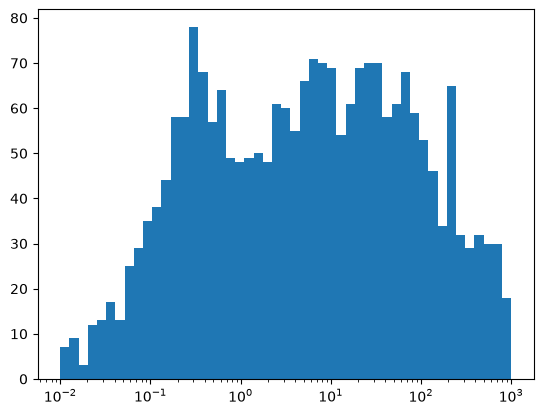

In [443]:
spatial_density_nir = (
    simulated_clusters_full["n_stars_gaianir-l"]
    / simulated_clusters_full["n_stars_for_rho_data_gaianir-l"]
)
spatial_density_dr3 = (
    np.where(
        simulated_clusters_full["n_stars_gaia_dr3"] != 0,
        simulated_clusters_full["n_stars_gaia_dr3"],
        0.1,
    )
    / simulated_clusters_full["n_stars_for_rho_data_gaia_dr3"]
)
density_ratio = spatial_density_nir / spatial_density_dr3
plt.hist(density_ratio**2, bins=np.geomspace(0.01, 1000))
plt.xscale("log")

In [445]:
(density_ratio > 1).sum() / len(density_ratio)

np.float64(0.693126022913257)

## Aside: checking regions

In [52]:
from scipy.stats import binned_statistic

In [94]:
region_name = "180.000_0.000"
region = pd.read_parquet(RESULTS_DIRECTORY / f"regions/{region_name}.parquet")

with open(RESULTS_DIRECTORY / f"regions/{region_name}_metadata.pickle", 'rb') as file:
    region_metadata = pickle.load(file)

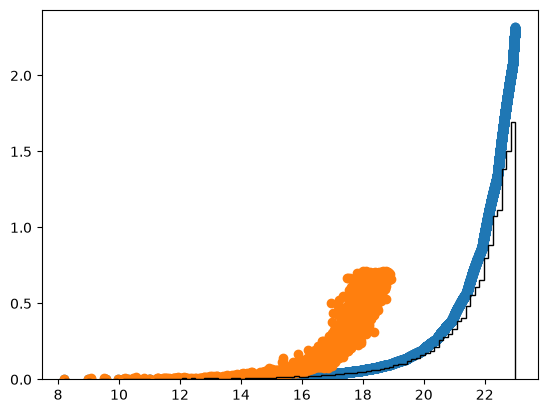

In [95]:
plt.scatter(region["gaianir_n"], region["parallax_error_gaianir-l"])
plt.scatter(region["gaianir_n"], region["parallax_error_gaia_dr5"])

means, edges, _ = binned_statistic(
    region["gaianir_n"], np.abs(region["parallax_true"] - region["parallax_gaianir-l"]), bins=100
)
plt.stairs(means, edges, color="k")

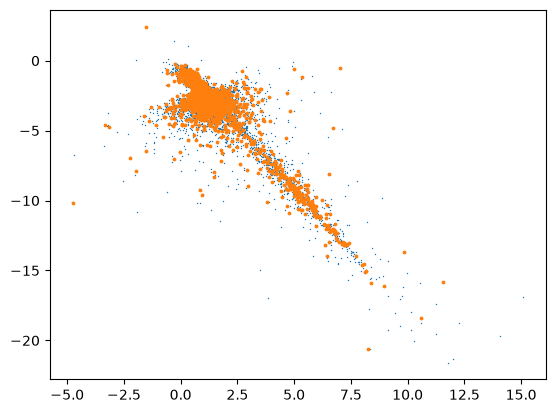

In [96]:
good_nir = region.query("distance > 2 and gaianir_n < 21")
good_gaia = region.query("distance > 2 and gaia_dr3_g < 21")

plt.scatter(good_nir['pmra_gaianir-l'], good_nir['pmdec_gaianir-l'], s=1, linewidths=0)
plt.scatter(good_gaia['pmra_gaia_dr5'], good_gaia['pmdec_gaia_dr5'], s=3)

[Text(0.5, 0, 'Distance [kpc]'), Text(0, 0.5, 'Extinction ($A_V$)')]

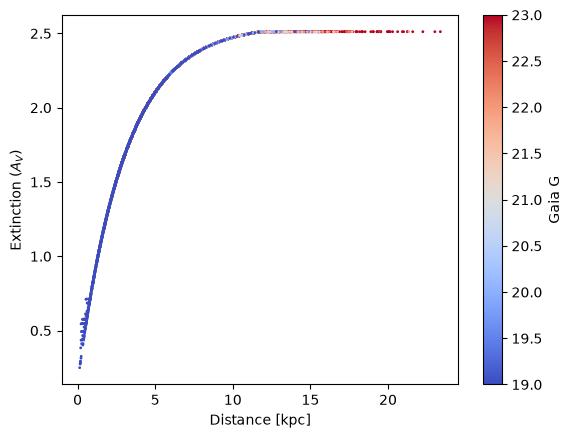

In [97]:
good_region = region.query("`uncrowded_gaianir-l`").sort_values(
    "gaia_dr3_g", ascending=False
)

points = plt.scatter(
    good_region["distance"],
    good_region["extinction"],
    s=1,
    c=good_region["gaia_dr3_g"],
    vmin=19,
    vmax=23,
    cmap="coolwarm",
)
plt.colorbar(points, label="Gaia G")
plt.gca().set(xlabel="Distance [kpc]", ylabel="Extinction ($A_V$)")

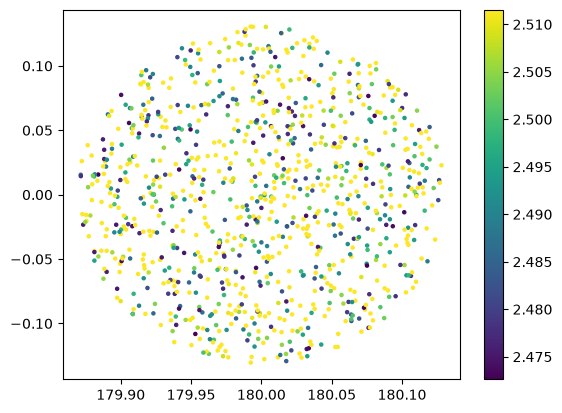

In [98]:
sample = good_region.query("distance > 10")
points = plt.scatter(sample['l'], sample['b'], c=sample['extinction_planck'], s=5)
plt.colorbar(points)

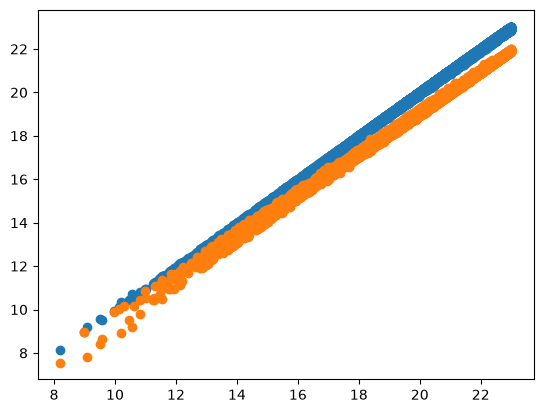

In [99]:
plt.scatter(good_region['gaianir_n'], good_region['gaianir_j'])
plt.scatter(good_region['gaianir_n'], good_region['gaianir_k'])

## Aside: checking clusters

In [111]:
members = pd.read_parquet(RESULTS_DIRECTORY / f"clusters/berkeley_29/{region_name}_20000.000.parquet")

In [112]:
members.keys()

Index(['simulated_id', 'ra', 'dec', 'l', 'b', 'mass', 'temperature',
       'luminosity', 'log_g', 'gaianir_n', 'gaianir_r', 'gaianir_j',
       'gaianir_h', 'gaianir_k', 'g_effective_gaia', 'pmra_gaianir-l_combined',
       'pmra_error_gaianir-l_combined', 'pmdec_gaianir-l_combined',
       'pmdec_error_gaianir-l_combined', 'parallax_gaianir-l_combined',
       'parallax_error_gaianir-l_combined', 'gaianir-l',
       'pmra_gaianir-m_combined', 'pmra_error_gaianir-m_combined',
       'pmdec_gaianir-m_combined', 'pmdec_error_gaianir-m_combined',
       'parallax_gaianir-m_combined', 'parallax_error_gaianir-m_combined',
       'gaianir-m', 'pmra_gaia_dr5', 'pmra_error_gaia_dr5', 'pmdec_gaia_dr5',
       'pmdec_error_gaia_dr5', 'parallax_gaia_dr5', 'parallax_error_gaia_dr5',
       'gaia_dr5', 'pmra_gaia_dr4', 'pmra_error_gaia_dr4', 'pmdec_gaia_dr4',
       'pmdec_error_gaia_dr4', 'parallax_gaia_dr4', 'parallax_error_gaia_dr4',
       'gaia_dr4'],
      dtype='str')

In [113]:
members['gaianir-l'].sum(), members['gaianir-m'].sum(), members['gaia_dr5'].sum()

(np.int64(544), np.int64(540), np.int64(11))

In [114]:
region['n-k'] = region['gaianir_n'] - region['gaianir_k']
members['n-k'] = members['gaianir_n'] - members['gaianir_k']

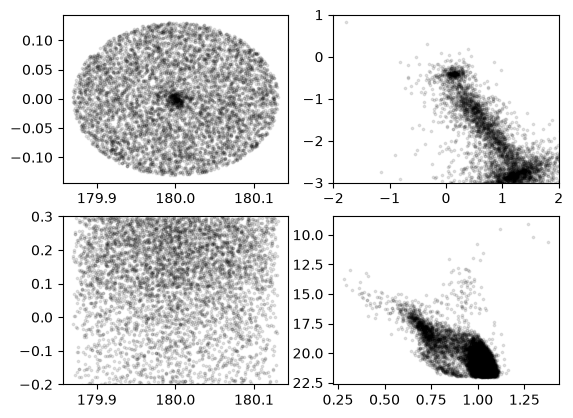

In [120]:
region_good = region.query("`uncrowded_gaianir-l` and gaianir_n < 22 and `parallax_gaianir-l` < 0.3")
members_good = members.query("`gaianir-l` and gaianir_n < 22").rename(
    columns={"parallax_gaianir-l_combined": "parallax_gaianir-l"}
)

fig, ax = plt.subplots(nrows=2, ncols=2)
ax = ax.flatten()

x_labels = ["l", "pmra_gaianir-l_combined", "l", "n-k"]
y_labels = ["b", "pmdec_gaianir-l_combined", "parallax_gaianir-l", "gaianir_n"]
for i, (x_label, y_label) in enumerate(zip(x_labels, y_labels)):
    ax[i].scatter(
        members_good[x_label], members_good[y_label], color="k", s=3, alpha=0.1
    )
    ax[i].scatter(
        region_good[x_label], region_good[y_label], color="k", s=3, alpha=0.1
    )

ax[1].set(xlim=(-2, 2), ylim=(-3, 1))
ax[2].set(ylim=(-0.2, 0.3))
ax[3].invert_yaxis()

[(-0.2, 0.3)]

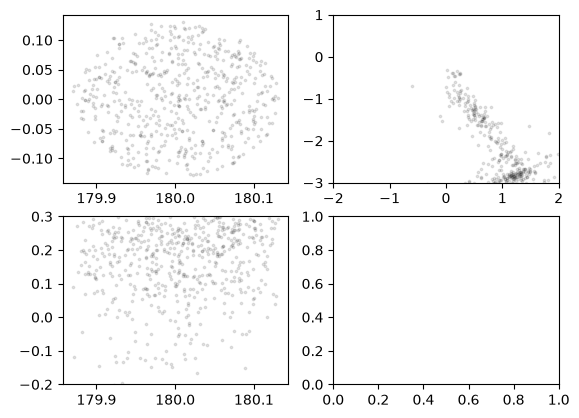

In [119]:
region_good = region.query("`uncrowded_gaia` and gaia_dr3_g < 20 and parallax_gaia_dr5 < 0.3")
members_good = members.query("gaia_dr5 and g_effective_gaia < 20")
fig, ax = plt.subplots(nrows=2, ncols=2)
ax = ax.flatten()

x_labels = ["l", "pmra_gaia_dr5", "l"]
y_labels = ["b", "pmdec_gaia_dr5", "parallax_gaia_dr5"]
for i, (x_label, y_label) in enumerate(zip(x_labels, y_labels)):
    ax[i].scatter(
        members_good[x_label], members_good[y_label], color="k", s=3, alpha=0.1
    )
    ax[i].scatter(
        region_good[x_label], region_good[y_label], color="k", s=3, alpha=0.1
    )

ax[1].set(xlim=(-2, 2), ylim=(-3, 1))
ax[2].set(ylim=(-0.2, 0.3))

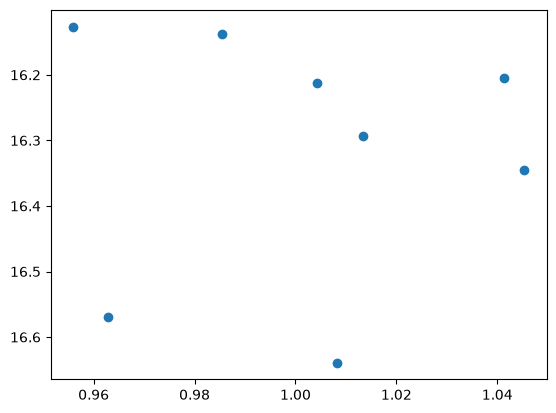

In [117]:
plt.scatter(
    members_good["gaianir_n"] - members_good["gaianir_k"], members_good["gaianir_n"]
)
plt.gca().invert_yaxis()

## Aside: checking simulated clusters

In [137]:
sample = simulated_clusters.query("l==330 and cluster=='pleiades'")

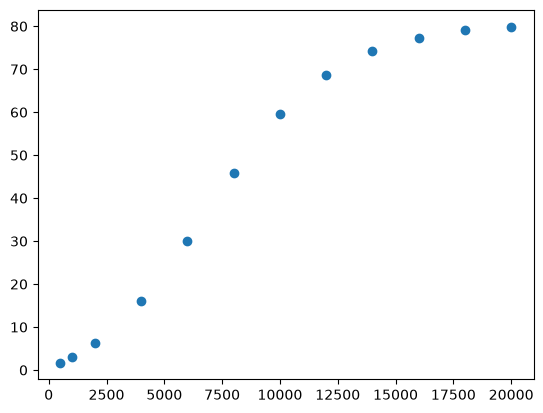

In [138]:
plt.scatter(sample['distance'], sample['extinction'])

## Aside: how to measure region densities

In [205]:
region_name = "180.000_0.000"
region = pd.read_parquet(RESULTS_DIRECTORY / f"regions/{region_name}.parquet")

with open(RESULTS_DIRECTORY / f"regions/{region_name}_metadata.pickle", 'rb') as file:
    region_area = pickle.load(file)['area']

region_area

np.float64(0.050505050505050504)

In [206]:
region

,pop,mass_initial,age,Fe/H_initial,mass,distance,l,b,logL,logTeff,...,pmra_gaia_dr5,pmdec_gaia_dr5,parallax_gaia_dr5,pmra_gaianir-l_combined,pmdec_gaianir-l_combined,pmra_gaianir-m_combined,pmdec_gaianir-m_combined,uncrowded_gaia,uncrowded_gaianir-m,uncrowded_gaianir-l
0,1.0,0.612014,14.000000,-1.463024,0.611900,2.785709,180.058146,-0.053831,-0.548766,3.735221,...,-5.852148,-3.166233,0.511238,-5.819665,-3.141737,-5.821262,-3.141495,True,True,True
1,1.0,0.182820,14.000000,-1.323171,0.182815,3.167206,179.975184,0.030744,-2.140187,3.582697,...,NaN,NaN,NaN,5.934904,-9.545443,5.841306,-9.682153,True,True,True
2,1.0,0.165244,14.000000,-0.815975,0.165241,3.369965,180.012787,0.072760,-2.294236,3.560152,...,NaN,NaN,NaN,0.101591,1.055779,-0.032899,1.716864,True,True,True
3,1.0,0.614889,14.000000,-1.421813,0.614773,5.337679,179.978282,-0.059627,-0.540602,3.735608,...,-3.567324,-1.669798,-0.041420,-3.593410,-1.691061,-3.494920,-1.665905,True,True,True
4,1.0,0.174108,14.000000,-2.044102,0.174104,6.112912,180.046270,0.045046,-2.132218,3.596509,...,NaN,NaN,NaN,0.717205,3.570581,-2.021629,2.259791,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23572,10.0,0.388413,7.115527,-0.550371,0.388406,22.474089,180.071803,-0.090404,-1.603978,3.579651,...,NaN,NaN,NaN,0.856999,-1.547587,5.149704,-2.459192,True,True,True
23573,10.0,0.407194,7.440575,-0.139036,0.407186,22.737046,179.936525,-0.102837,-1.619862,3.563929,...,NaN,NaN,NaN,-0.466865,-2.319251,2.541439,-3.260084,True,True,True
23574,10.0,0.479691,8.431151,0.129251,0.479680,22.959595,180.038769,0.050955,-1.475667,3.564586,...,NaN,NaN,NaN,-0.542058,-0.149675,-0.600562,-3.588712,True,True,True
23575,10.0,0.552484,8.980711,-0.594071,0.552454,22.912241,180.076273,-0.085331,-1.024957,3.639644,...,NaN,NaN,NaN,0.162773,-1.623940,-1.497527,-1.984867,True,True,True


In [207]:
region['uncrowded_gaia'].sum()

np.int64(23557)

In [208]:
mission = "gaianir-l"

true_parallax = 0.5
subsample = region.loc[
    (region[f"parallax_{mission}"] > true_parallax - 0.05)
    & (region[f"parallax_{mission}"] < true_parallax + 0.05)
    & (region[f"uncrowded_{mission.replace("_dr4", "").replace("_dr5", "")}"])
]

In [209]:
simulated_clusters.query("l==0 and b==0 and cluster=='berkeley_29'")

,cluster,l,b,path,path_region,distance,extinction,differential_extinction,ra,dec,pmra,pmdec,radial_velocity,mass,log_age,metallicity,r_core,r_tidal,virial_ratio
0,berkeley_29,0.0,0.0,clusters/berkeley_29/0.000_0.000_2000.000.parquet,regions/0.000_0.000.parquet,2000.0,0.928711,0.092871,266.404988,-28.936178,-0.197843,-1.905723,-12.880099,1500,9.5,-0.5,2.5,15,0.5
1,berkeley_29,0.0,0.0,clusters/berkeley_29/0.000_0.000_4000.000.parquet,regions/0.000_0.000.parquet,4000.0,1.484375,0.148438,266.404988,-28.936178,-0.419851,-1.478599,-12.880215,1500,9.5,-0.5,2.5,15,0.5
2,berkeley_29,0.0,0.0,clusters/berkeley_29/0.000_0.000_6000.000.parquet,regions/0.000_0.000.parquet,6000.0,1.556641,0.155664,266.404988,-28.936178,-0.905820,-2.011096,-12.880469,1500,9.5,-0.5,2.5,15,0.5
3,berkeley_29,0.0,0.0,clusters/berkeley_29/0.000_0.000_8000.000.parquet,regions/0.000_0.000.parquet,8000.0,1.902344,0.190234,266.404988,-28.936178,-0.861475,-1.806651,-12.890350,1500,9.5,-0.5,2.5,15,0.5
4,berkeley_29,0.0,0.0,clusters/berkeley_29/0.000_0.000_10000.000.par...,regions/0.000_0.000.parquet,10000.0,2.517578,0.251758,266.404988,-28.936178,-4.507598,-7.700543,-12.880530,1500,9.5,-0.5,2.5,15,0.5
5,berkeley_29,0.0,0.0,clusters/berkeley_29/0.000_0.000_12000.000.par...,regions/0.000_0.000.parquet,12000.0,1.770508,0.177051,266.404988,-28.936178,-4.099158,-6.978727,-12.880235,1500,9.5,-0.5,2.5,15,0.5
6,berkeley_29,0.0,0.0,clusters/berkeley_29/0.000_0.000_14000.000.par...,regions/0.000_0.000.parquet,14000.0,2.654297,0.265430,266.404988,-28.936178,-3.622457,-6.160152,-12.880110,1500,9.5,-0.5,2.5,15,0.5
7,berkeley_29,0.0,0.0,clusters/berkeley_29/0.000_0.000_16000.000.par...,regions/0.000_0.000.parquet,16000.0,2.119141,0.211914,266.404988,-28.936178,-3.176939,-5.402074,-12.880037,1500,9.5,-0.5,2.5,15,0.5
8,berkeley_29,0.0,0.0,clusters/berkeley_29/0.000_0.000_18000.000.par...,regions/0.000_0.000.parquet,18000.0,1.855469,0.185547,266.404988,-28.936178,-2.804452,-4.769909,-12.879989,1500,9.5,-0.5,2.5,15,0.5
9,berkeley_29,0.0,0.0,clusters/berkeley_29/0.000_0.000_20000.000.par...,regions/0.000_0.000.parquet,20000.0,2.728516,0.272852,266.404988,-28.936178,-2.502843,-4.258248,-12.879958,1500,9.5,-0.5,2.5,15,0.5


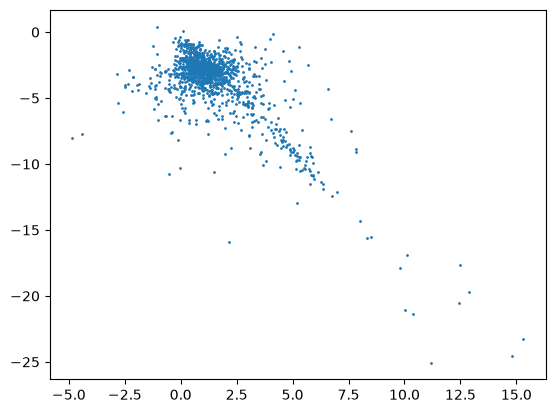

In [210]:
plt.scatter(subsample[f'pmra_{mission}'], subsample[f'pmdec_{mission}'], s=1, alpha=1)

In [211]:
X = subsample[[f'pmra_{mission}', f'pmdec_{mission}']].to_numpy()
mixture = GaussianMixture(n_components=5)
_ = mixture.fit(X)
mixture_pdf_values = np.exp(
    mixture.score_samples(X)
)

In [212]:
mean = np.mean(X, axis=0)
cov = np.cov(X.T)
single_multivariate = multivariate_normal(mean, cov)
single_pdf_values = single_multivariate.pdf(X)

In [222]:
kde = gaussian_kde(X.T, bw_method="scott")
kde_pdf_values = kde.pdf(X.T)

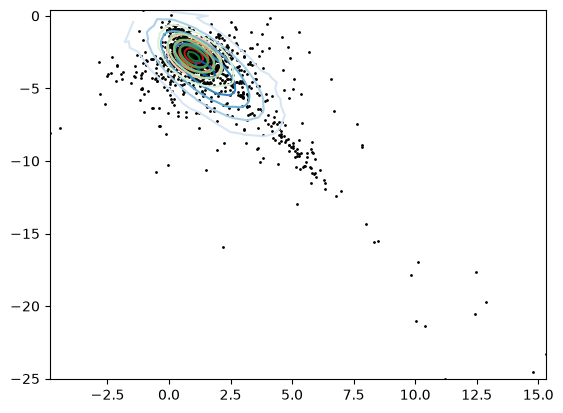

In [230]:
x, y = subsample[f"pmra_{mission}"], subsample[f"pmdec_{mission}"]
plt.tricontour(x, y, mixture_pdf_values, levels=5, cmap="Reds")
plt.tricontour(x, y, single_pdf_values, levels=5, cmap="Blues")
plt.tricontour(x, y, kde_pdf_values, levels=5, cmap="Greens")
plt.scatter(subsample[f"pmra_{mission}"], subsample[f"pmdec_{mission}"], s=1, color="k")

[Text(0.5, 0, 'KDE PDF value'), Text(0, 0.5, 'Scaled residual')]

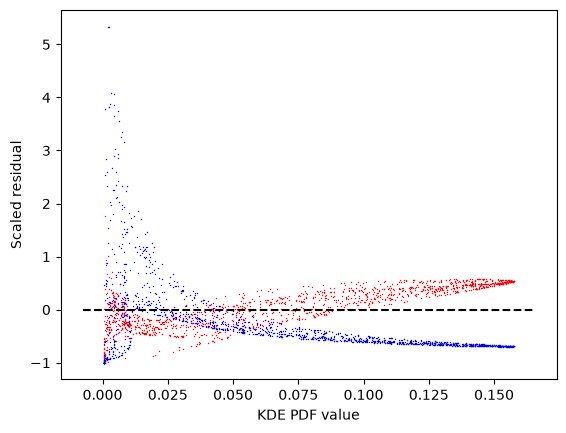

In [215]:
plt.scatter(
    kde_pdf_values,
    (mixture_pdf_values - kde_pdf_values) / kde_pdf_values,
    c="r",
    s=1,
    linewidths=0,
)
plt.scatter(
    kde_pdf_values,
    (single_pdf_values - kde_pdf_values) / kde_pdf_values,
    c="b",
    s=1,
    linewidths=0,
)
plt.plot(plt.gca().get_xlim(), [0, 0], "k--")
plt.gca().set(xlabel="KDE PDF value", ylabel="Scaled residual")

Welp, it really looks like doing a KDE is necessary to get a good density estimate. Oh well!